# Sesión 3 · DBSCAN: zonas conectadas y puntos aislados
**18 de septiembre · 120 minutos.** Objetivos: formalizar conectividad, ejecutar un caso manual y
explicar sensibilidad a escala y conteos. Leer la sección 5 de las notas. El análisis es transductivo:
describe el conjunto ajustado; no implementamos una regla de asignación para nuevos viajes.

In [1]:
from pathlib import Path
import sys, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from threadpoolctl import threadpool_limits

# Funciona desde la raíz, desde esta carpeta o desde docente/.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'datasets/semana-08').is_dir())
sys.path.insert(0, str(ROOT / 'notebooks/semana-08'))
from movilidad import (load_data, setup, savefig, save_table, spatial_axes,
                       ellipses, safe_silhouette, density_grid, COLORS, DATA)
setup()
threadpool_limits(limits=2)
frame = load_data()
X = frame[['x_km', 'y_km']].to_numpy()
print(f'Desarrollo: {len(frame):,} recogidas. Unidades: km. Semilla: 42.')
print('Test temporal cerrado hasta congelar el modelo.')
display(frame.head(3))

Desarrollo: 6,000 recogidas. Unidades: km. Semilla: 42.
Test temporal cerrado hasta congelar el modelo.


,source_row,pickup_datetime,pickup_longitude,pickup_latitude,x_km,y_km,fare_amount,passenger_count,dropoff_longitude,dropoff_latitude
0,32038,2014-01-01 00:01:00+00:00,-73.991493,40.735202,0.156182,-0.148260,5.5,5,-74.001727,40.727767
1,132584,2014-01-01 00:29:37+00:00,-74.008090,40.740434,-1.251817,0.416562,8.0,2,-73.996088,40.726627
2,190530,2014-01-01 00:54:07+00:00,-73.981944,40.778096,0.907251,4.622599,7.5,1,-73.967887,40.801430


## 1. Vecindades y núcleo
$$N_\varepsilon(x_i)=\{x_j:\|x_i-x_j\|\leq\varepsilon\}.$$
Un punto es núcleo si $|N_\varepsilon(x_i)|\geq m$, **incluyéndose a sí mismo**.
La alcanzabilidad directa requiere que el punto de partida sea núcleo; no es simétrica en general.
Los núcleos conectados forman componentes. Un punto frontera se añade sin expandir la búsqueda desde él.

### Para resolver

En una línea: A=0, B=0.1, C=0.2, D=0.3, E=0.8. Use eps=0.115 y min_samples=3. Enumere vecinos, núcleos, fronteras y ruido.

**Mi respuesta y evidencia:**

_Escriba aquí su razonamiento; incluya unidades y una limitación._

D:\Documentos\Universidad Externado\Pregrado en Ciencia de Datos\Machine Learning 2\.venv-week4\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "D:\Documentos\Universidad Externado\Pregrado en Ciencia de Datos\Machine Learning 2\.venv-week4\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


Vecinos: [[np.int64(0), np.int64(1)], [np.int64(0), np.int64(1), np.int64(2)], [np.int64(1), np.int64(2), np.int64(3)], [np.int64(2), np.int64(3)], [np.int64(4)]]
Núcleo: [1 2] | etiquetas: [ 0  0  0  0 -1]


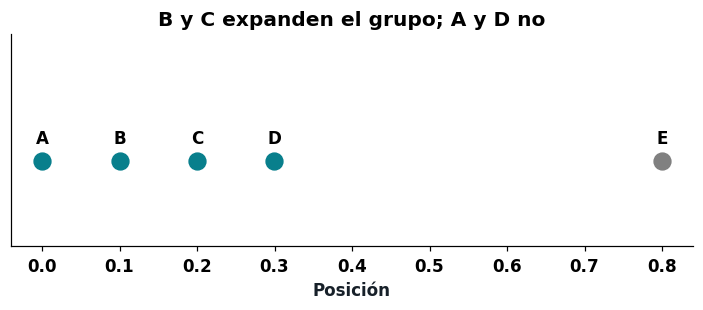

In [2]:
from sklearn.cluster import DBSCAN, KMeans
from sklearn.neighbors import NearestNeighbors
tiny=np.c_[[0,.1,.2,.3,.8],np.zeros(5)]
manual=DBSCAN(eps=.115,min_samples=3).fit(tiny)
neighbors=NearestNeighbors(radius=.115).fit(tiny).radius_neighbors(tiny,return_distance=False)
print('Vecinos:',[list(v) for v in neighbors])
print('Núcleo:',manual.core_sample_indices_,'| etiquetas:',manual.labels_)
assert set(manual.core_sample_indices_)=={1,2}
assert manual.labels_[4]==-1
assert len(set(manual.labels_[:4]))==1
fig,ax=plt.subplots(figsize=(8,2.5))
for i,(x,y) in enumerate(tiny):
    ax.scatter(x,y,s=120,color='grey' if i==4 else COLORS[0])
    ax.annotate('ABCDE'[i],(x,y),xytext=(0,12),textcoords='offset points',ha='center')
ax.set(xlabel='Posición',ylim=(-.1,.15),yticks=[],title='B y C expanden el grupo; A y D no')
savefig(fig,'10_dbscan_manual')

## 2. Un éxito y una limitación
DBSCAN puede recuperar formas no convexas. Una única pareja eps/min_samples puede no representar
regiones con densidades muy diferentes. El ruido es relativo a esa escala y a esa muestra.

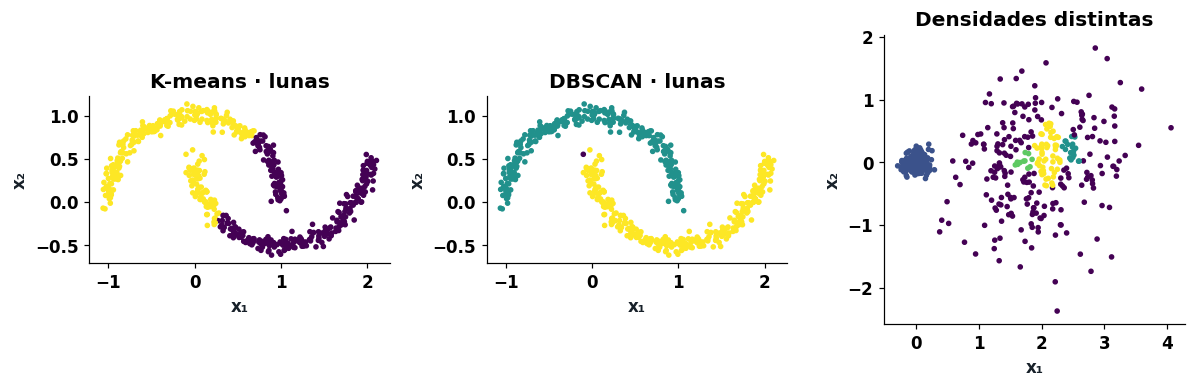

In [3]:
from sklearn.datasets import make_moons
moons,_=make_moons(n_samples=600,noise=.05,random_state=42)
rng=np.random.default_rng(42)
unequal=np.vstack([rng.normal([0,0],.10,(300,2)),rng.normal([2,0],.65,(300,2))])
fig,axes=plt.subplots(1,3,figsize=(11,3.6))
experiments=[(moons,KMeans(2,n_init=10,random_state=42).fit_predict(moons),'K-means · lunas'),
             (moons,DBSCAN(eps=.15,min_samples=5).fit_predict(moons),'DBSCAN · lunas'),
             (unequal,DBSCAN(eps=.15,min_samples=10).fit_predict(unequal),'Densidades distintas')]
for ax,(points,labels,title) in zip(axes,experiments):
    ax.scatter(*points.T,c=labels,cmap='viridis',s=7)
    ax.set(title=title,xlabel='x₁',ylabel='x₂',aspect='equal')
fig.tight_layout(); savefig(fig,'11_dbscan_geometrias')

## 3. Vecinos en kilómetros
En `kneighbors(X)`, al pasar X explícitamente, el punto se incluye como vecino de distancia cero.
La columna m−1 representa el m-ésimo vecino contando el propio punto. El codo orienta; no prueba un eps óptimo.

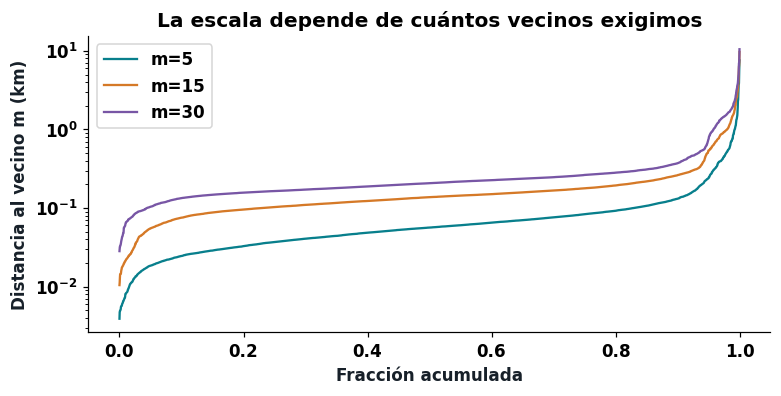

,eps,min_samples,n_clusters,noise_fraction,min_cluster,max_cluster,silhouette
0,0.1,5,95,0.112000,4,3143,-0.298579
1,0.1,15,66,0.580333,11,214,0.460007
2,0.1,30,8,0.918167,33,96,0.835232
3,0.2,5,15,0.051333,5,5384,0.000894
4,0.2,15,13,0.097500,4,5033,-0.251399
5,0.2,30,21,0.302500,9,2822,-0.061677
6,0.4,5,15,0.021167,5,5498,0.083521
7,0.4,15,3,0.050833,113,5457,0.679390
8,0.4,30,5,0.056667,32,5388,0.400366
9,0.8,5,6,0.007833,6,5593,0.219727


In [4]:
fig,ax=plt.subplots(figsize=(8,3.5))
for m in [5,15,30]:
    distances,_=NearestNeighbors(n_neighbors=m).fit(X).kneighbors(X)
    kth=np.sort(distances[:,m-1])
    ax.plot(np.arange(len(kth))/len(kth),kth,label=f'm={m}')
ax.set(xlabel='Fracción acumulada',ylabel='Distancia al vecino m (km)',
       title='La escala depende de cuántos vecinos exigimos',yscale='log'); ax.legend()
savefig(fig,'12_vecinos')
rows=[]
for eps in [.1,.2,.4,.8,1.6]:
    for m in [5,15,30]:
        model=DBSCAN(eps=eps,min_samples=m).fit(X)
        labels=model.labels_; sizes=pd.Series(labels[labels!=-1]).value_counts()
        rows.append(dict(eps=eps,min_samples=m,n_clusters=len(sizes),noise_fraction=np.mean(labels==-1),
                         min_cluster=int(sizes.min()) if len(sizes) else 0,
                         max_cluster=int(sizes.max()) if len(sizes) else 0,
                         silhouette=safe_silhouette(X,labels)))
results=pd.DataFrame(rows); display(results); save_table(results,'dbscan_sensibilidad')

### Para resolver

Seleccione una configuración con un argumento espacial y otro de sensibilidad. Explique por qué no basta ordenar por silhouette.

**Mi respuesta y evidencia:**

_Escriba aquí su razonamiento; incluya unidades y una limitación._

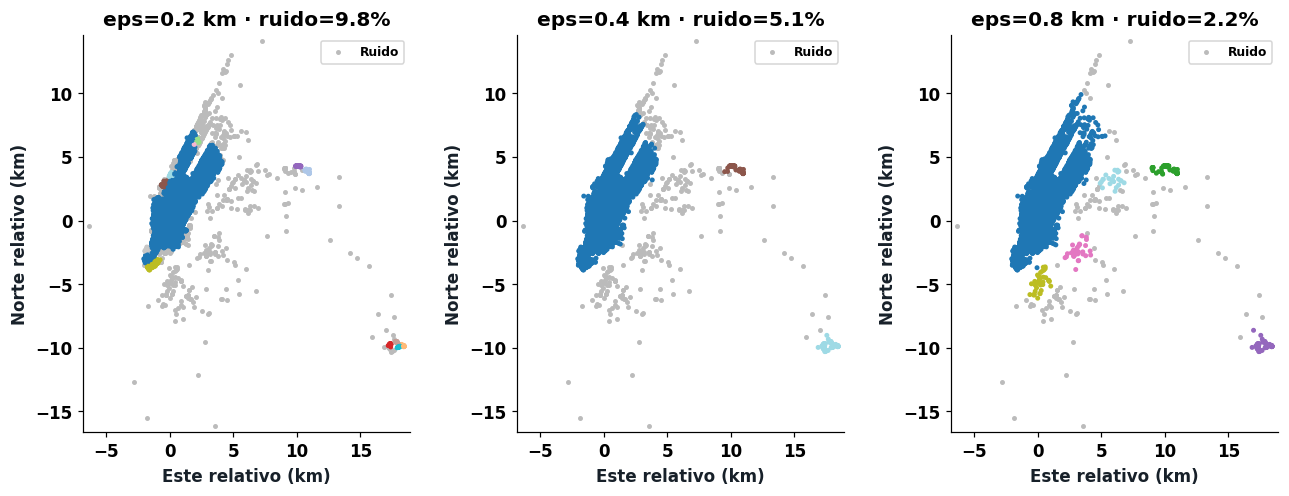

Completa grupos 3 ruido 0.050833333333333335
Mitad, m fijo grupos 5 ruido 0.06133333333333333
Mitad, m aproximado grupos 5 ruido 0.050666666666666665
Reducir m aproximadamente conserva un umbral de conteo, no garantiza la misma partición.


In [5]:
# Configuración ilustrativa, fijada antes de mirar resultados; no se afirma que sea óptima.
chosen_eps,chosen_m=.4,15
fig,axes=plt.subplots(1,3,figsize=(12,4.5))
for ax,eps in zip(axes,[.2,.4,.8]):
    model=DBSCAN(eps=eps,min_samples=chosen_m).fit(X)
    labels=model.labels_
    ax.scatter(*X[labels==-1].T,s=5,color='#bbbbbb',label='Ruido')
    ax.scatter(*X[labels!=-1].T,c=labels[labels!=-1],cmap='tab20',s=5)
    spatial_axes(ax,X,f'eps={eps} km · ruido={np.mean(labels==-1):.1%}')
    ax.legend(fontsize=8)
fig.tight_layout(); savefig(fig,'13_dbscan_espacial')
half=np.random.default_rng(42).choice(len(X),len(X)//2,replace=False)
for label,points,m in [('Completa',X,15),('Mitad, m fijo',X[half],15),('Mitad, m aproximado',X[half],8)]:
    lab=DBSCAN(eps=.4,min_samples=m).fit_predict(points)
    print(label, 'grupos',len(set(lab)-{-1}),'ruido',np.mean(lab==-1))
print('Reducir m aproximadamente conserva un umbral de conteo, no garantiza la misma partición.')

## 4. Comité de movilidad
Compare los tres mapas sobre los mismos límites. Proponga dos zonas candidatas para estudio y una ubicación
que requiera revisión. Describa las zonas mediante rangos de coordenadas; no invente nombres de barrios.
Si no hay evidencia suficiente, explique por qué. No use el centroide como ubicación operativa automática.

Complete: **Observo → interpreto → recomendaría estudiar → vigilaría → no puedo concluir**.
La defensa dura 90 segundos por equipo. Consulte la guía de laboratorio para los criterios formativos.

### Para resolver

Ticket: ¿puede eps ser menor que el diámetro de un grupo? ¿Todo punto frontera une dos grupos? ¿Ruido equivale a error?

**Mi respuesta y evidencia:**

_Escriba aquí su razonamiento; incluya unidades y una limitación._

## Fuentes y reproducción
- Microcurrículo y guía docente ML2, sesiones 19–24; adaptación del cuaderno histórico del profesor.
- [GMM](https://scikit-learn.org/stable/modules/mixture.html), [KDE](https://scikit-learn.org/stable/modules/density.html), [clustering](https://scikit-learn.org/stable/modules/clustering.html).
- Dataset suministrado por el docente; ver `datasets/semana-08/README.md` y `manifest.json`.
- Dependencias fijadas en `requirements-week8.txt`. Inicie el kernel en una carpeta del paquete.